# Tratamiento de los valores perdidos

Cargamos los datos.

En esta ocasión cargamos los datos desde la carpeta /content/sample_data/ de Colab. Es necesario ubicar ahí el archivo `Ejemplo_valores_perdidos.csv`

In [69]:
import os
import pandas as pd
def cargar_datos():
    data = pd.read_csv(r"C:\americo\ia_dema\z-ejercicios_kaggle\Vehicles_elect_2025\data_real\electric_vehicles_spec_2025.csv")
    return data

data = cargar_datos()

Necesitaremos una versión de scikit-learn superior a la que viene instalada en colab (1.2.2 -> 1.5.0)

## Visualización de los datos

Lo primero que debemos hacer es visualizar los datos

In [70]:
data

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Zeekr,7X Premium RWD,210,71.0,Lithium-ion,NaN,440.0,148,365,6.0,...,2000.0,539,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...
474,Zeekr,X Core RWD (MY25),190,49.0,Lithium-ion,NaN,343.0,148,265,5.9,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475,Zeekr,X Long Range RWD (MY25),190,65.0,Lithium-ion,NaN,343.0,146,360,5.6,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...
476,Zeekr,X Privilege AWD (MY25),190,65.0,Lithium-ion,NaN,543.0,153,350,3.8,...,1600.0,362,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...


Tambien podemos visualizar un numero determinado para mayor comodidad

In [71]:
data.head(n=10)

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
5,Aiways,U6,160,60.0,Lithium-ion,NaN,315.0,150,350,7.0,...,NaN,472,5,FWD,JC - Medium,4805,1880,1641,SUV,https://ev-database.org/car/1766/Aiways-U6
6,Alfa,Romeo Junior Elettrica 54 kWh,150,50.8,Lithium-ion,102.0,260.0,128,320,9.0,...,0.0,400,5,FWD,JB - Compact,4173,1781,1532,SUV,https://ev-database.org/car/2184/Alfa-Romeo-Ju...
7,Alfa,Romeo Junior Elettrica 54 kWh Veloce,200,50.8,Lithium-ion,102.0,345.0,164,310,6.0,...,0.0,400,5,FWD,JB - Compact,4173,1781,1505,SUV,https://ev-database.org/car/2185/Alfa-Romeo-Ju...
8,Alpine,A290 Electric 180 hp,160,52.0,Lithium-ion,184.0,285.0,138,310,7.4,...,500.0,326,5,FWD,B - Compact,3997,1823,1512,Hatchback,https://ev-database.org/car/2268/Alpine-A290-E...
9,Alpine,A290 Electric 220 hp,170,52.0,Lithium-ion,184.0,300.0,144,305,6.4,...,500.0,326,5,FWD,B - Compact,3997,1823,1512,Hatchback,https://ev-database.org/car/2269/Alpine-A290-E...


Tambien tenemos la opcion de realizar un "resumen estadistico" de cada una de las variables.

In [72]:
data.describe()

,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,478.000000,478.000000,276.000000,471.000000,478.000000,478.000000,478.000000,477.000000,452.000000,478.000000,478.000000,478.000000,478.000000
mean,185.487448,74.043724,485.293478,498.012739,162.903766,393.179916,6.882636,125.008386,1052.261062,5.263598,4678.506276,1887.359833,1601.125523
std,34.252773,20.331058,1210.819733,241.461128,34.317532,103.287335,2.730696,58.205012,737.851774,1.003961,369.210573,73.656807,130.754851
min,125.000000,21.300000,72.000000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3620.000000,1610.000000,1329.000000
25%,160.000000,60.000000,150.000000,305.000000,143.000000,320.000000,4.800000,80.000000,500.000000,5.000000,4440.000000,1849.000000,1514.000000
50%,180.000000,76.150000,216.000000,430.000000,155.000000,397.500000,6.600000,113.000000,1000.000000,5.000000,4720.000000,1890.000000,1596.000000
75%,201.000000,90.600000,324.000000,679.000000,177.750000,470.000000,8.200000,150.000000,1600.000000,5.000000,4961.000000,1939.000000,1665.000000
max,325.000000,118.000000,7920.000000,1350.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2080.000000,1986.000000


Todas las variables son de tipo numérico

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    object 
 1   model                      477 non-null    object 
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    object 
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    object 
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    object 

Una vez conocidos nuestros datos procedemos a analizar su completitud.<br>
Tenemos que saber cuantos valores perdidos tenemos de cada variable antes de tomar una decision sobre como proceder.

La función `isnull()` nos devuelve un Dataframe con las mismas filas y columnas que el original, pero en las celdas tenemos el 

valor booleano que nos informa de si en esa posición hay almacenado o no un valor perdido.

✅ .isnull() devuelve:

- True → Significa que el valor es nulo o faltante. Es decir, no hay ningún dato en esa celda o variable.

- False → Significa que el valor no es nulo, o sea, hay algo presente ahí (puede ser un número, texto, etc.).

In [74]:
data.isnull()
# data.notna()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
474,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
475,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
476,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


La función `sum()` nos hace una primera suma por columnas, de manera que sabemos cuántos valores perdidos hay en cada variable a estudiar.

In [ ]:
# 1. Calcula el conteo de nulos por columna
null_counts = data.isnull().sum()

# 2. Filtra solo > 0
null_counts = null_counts[null_counts > 0]

print("Columnas con valores nulos:")
print(null_counts)

# usamos lambda
# print(data.isnull().sum()[lambda x: x>0])

Columnas con valores nulos:
model                          1
number_of_cells              202
torque_nm                      7
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
dtype: int64


Otra opcion es calcular el porcentaje respecto al número de registros totales, que siempre es más representativo.

In [13]:
data.shape

(478, 22)

In [119]:
print("Porcentajes de valores perdidos por cada variable:")
Porcentajes_valores_perdidos_por_cada_variable = data.isnull().sum()/len(data.index)*100

Porcentajes_valores_perdidos_por_cada_variable = Porcentajes_valores_perdidos_por_cada_variable[Porcentajes_valores_perdidos_por_cada_variable > 0]

Porcentajes_valores_perdidos_por_cada_variable

Porcentajes de valores perdidos por cada variable:


model                         0.209205
number_of_cells              42.259414
torque_nm                     1.464435
fast_charging_power_kw_dc     0.209205
fast_charge_port              0.209205
towing_capacity_kg            5.439331
cargo_volume_l                0.209205
dtype: float64

In [120]:
sum(data.isnull().sum())/(data.shape[0]*data.shape[1])*100

2.272727272727273

# 4. Realizar diagramas de los valores perdidos que permitan ver su número y posición.

In [121]:
# Crear un DataFrame booleano que indique la presencia de valores perdidos
missing_data = data[data.columns[data.isnull().sum() > 0]]

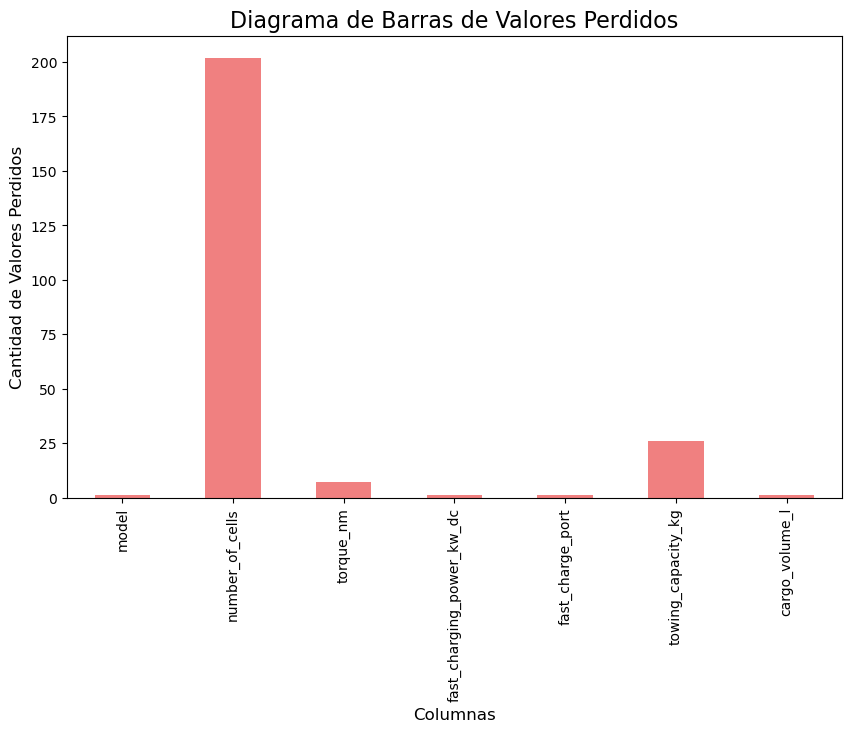

In [122]:
import matplotlib.pyplot as plt
# Calcular la cantidad de valores perdidos por columna
missing_values = missing_data.isnull().sum()

# Visualizar el diagrama de barras de valores perdidos
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='lightcoral')
plt.title('Diagrama de Barras de Valores Perdidos', fontsize=16)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Cantidad de Valores Perdidos', fontsize=12)
plt.show()

model                         0.209205
number_of_cells              42.259414
torque_nm                     1.464435
fast_charging_power_kw_dc     0.209205
fast_charge_port              0.209205
towing_capacity_kg            5.439331
cargo_volume_l                0.209205
dtype: float64

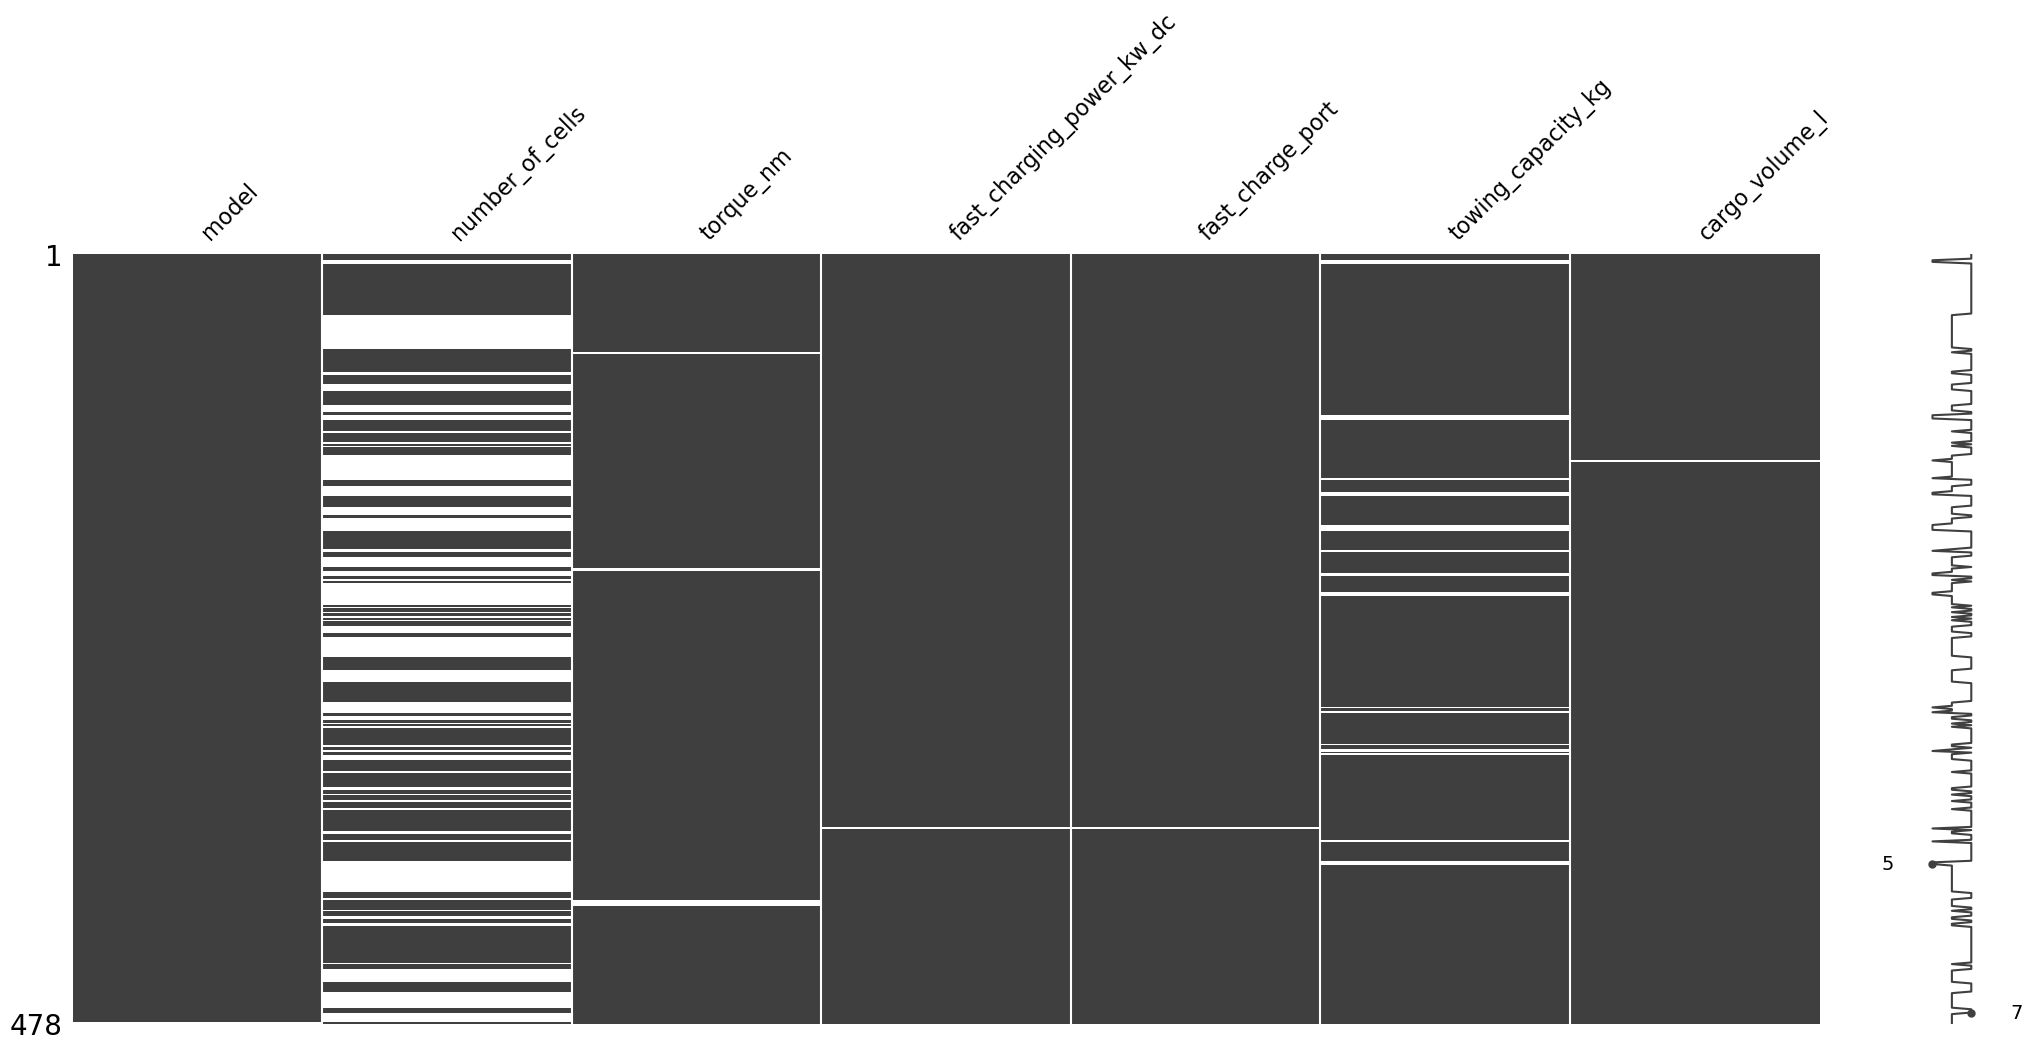

In [123]:
import missingno as msno
msno.matrix(missing_data);

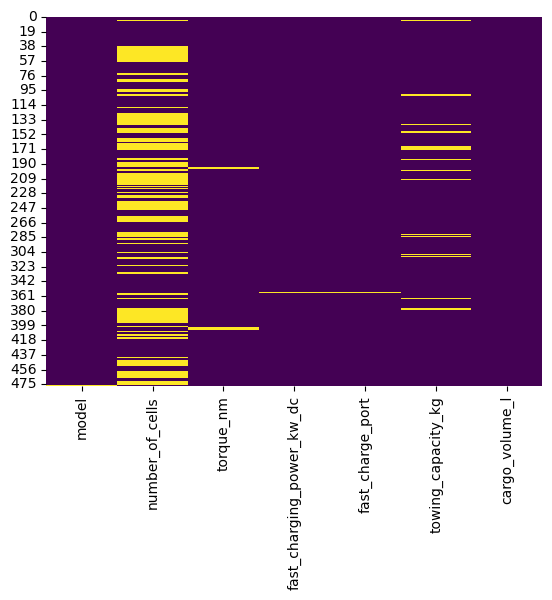

In [124]:
import seaborn as sns
sns.heatmap(missing_data.isnull(), cbar=False, cmap='viridis');

# 5. Realizar un gráfico de correlación de los valores perdidos.

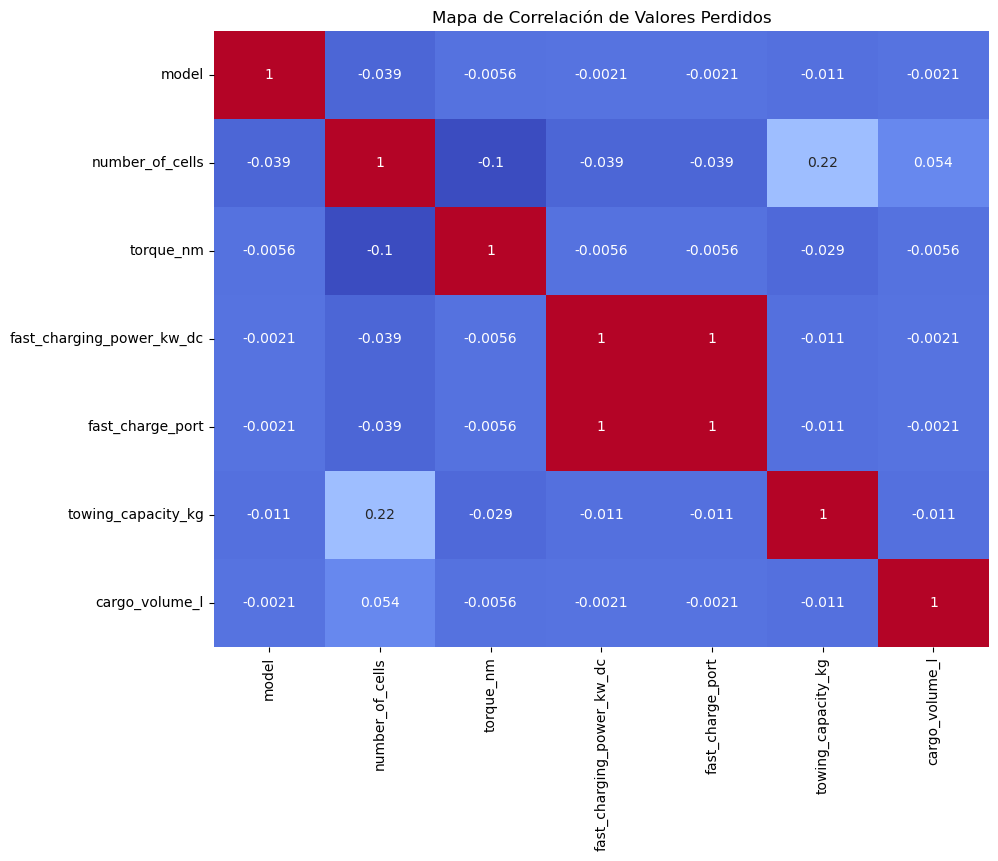

In [125]:
# Crear un DataFrame booleano que indique la presencia de valores perdidos
missing_data = data[data.columns[data.isnull().sum() > 0]].isnull()

# Crear un mapa de calor de la correlación entre columnas con valores perdidos
plt.figure(figsize=(10, 8))
sns.heatmap(missing_data.corr(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Mapa de Correlación de Valores Perdidos')
plt.show()

#6. Eliminar aquellas variables que tengan más de un 30% de valores perdidos.

model                         0.209205
number_of_cells              42.259414
torque_nm                     1.464435
fast_charging_power_kw_dc     0.209205
fast_charge_port              0.209205
towing_capacity_kg            5.439331
cargo_volume_l                0.209205
dtype: float64

In [127]:
data = cargar_datos()

In [128]:
data2 = data.copy()

for i in data2:
    if data2[i].isnull().sum()/len(data2.index) > 0.1:
        print("Elimino la columna", i)
        data2 = data2.drop(columns=i)

Elimino la columna number_of_cells


In [129]:
# Porcentaje de nulos por columna (en %)
missing_pct = data.isnull().mean() * 100

print("Porcentaje de valores faltantes por variable:")
print(missing_pct.round(2))

Porcentaje de valores faltantes por variable:
brand                         0.00
model                         0.21
top_speed_kmh                 0.00
battery_capacity_kWh          0.00
battery_type                  0.00
number_of_cells              42.26
torque_nm                     1.46
efficiency_wh_per_km          0.00
range_km                      0.00
acceleration_0_100_s          0.00
fast_charging_power_kw_dc     0.21
fast_charge_port              0.21
towing_capacity_kg            5.44
cargo_volume_l                0.21
seats                         0.00
drivetrain                    0.00
segment                       0.00
length_mm                     0.00
width_mm                      0.00
height_mm                     0.00
car_body_type                 0.00
source_url                    0.00
dtype: float64


In [130]:
# Columnas a borrar >30% nulos
to_drop = missing_pct[missing_pct > 30].index.tolist()
print("Eliminando estas columnas (>30% nulos):", to_drop)


Eliminando estas columnas (>30% nulos): ['number_of_cells']


In [131]:

# Crear copia sin esas columnas
data2 = data.drop(columns=to_drop)


In [132]:

# Verifica las nuevas dimensiones
print("Dimensiones original:", data.shape)
print("Dimensiones tras limpieza:", data2.shape)


Dimensiones original: (478, 22)
Dimensiones tras limpieza: (478, 21)


In [135]:
# Conserva sólo columnas con <=30% de nulos
data2 = data.loc[:, data.isnull().mean() <= 0.30]
data2.columns


Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'torque_nm', 'efficiency_wh_per_km', 'range_km',
       'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port',
       'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain',
       'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type',
       'source_url'],
      dtype='object')

In [136]:
print("Quedan columnas:", data2.columns.tolist())
print("Nueva forma:", data2.shape)


Quedan columnas: ['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh', 'battery_type', 'torque_nm', 'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port', 'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain', 'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type', 'source_url']
Nueva forma: (478, 21)


In [137]:
data.loc[:, data.apply(lambda x: x.isnull().sum() < 0.3 * len(data.index))]

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,235.0,156,225,7.0,67.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,235.0,149,225,7.0,67.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,345.0,158,280,5.9,79.0,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,345.0,158,280,6.2,79.0,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,310.0,156,315,7.5,78.0,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Zeekr,7X Premium RWD,210,71.0,Lithium-ion,440.0,148,365,6.0,240.0,...,2000.0,539,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...
474,Zeekr,X Core RWD (MY25),190,49.0,Lithium-ion,343.0,148,265,5.9,70.0,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475,Zeekr,X Long Range RWD (MY25),190,65.0,Lithium-ion,343.0,146,360,5.6,114.0,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...
476,Zeekr,X Privilege AWD (MY25),190,65.0,Lithium-ion,543.0,153,350,3.8,114.0,...,1600.0,362,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...


# 7. Calcular el porcentaje de valores perdidos una vez eliminadas esas variables.

## Porcentaje por variable

In [138]:
data2.isnull().sum()/len(data2.index)

brand                        0.000000
model                        0.002092
top_speed_kmh                0.000000
battery_capacity_kWh         0.000000
battery_type                 0.000000
torque_nm                    0.014644
efficiency_wh_per_km         0.000000
range_km                     0.000000
acceleration_0_100_s         0.000000
fast_charging_power_kw_dc    0.002092
fast_charge_port             0.002092
towing_capacity_kg           0.054393
cargo_volume_l               0.002092
seats                        0.000000
drivetrain                   0.000000
segment                      0.000000
length_mm                    0.000000
width_mm                     0.000000
height_mm                    0.000000
car_body_type                0.000000
source_url                   0.000000
dtype: float64

## Porcentaje total

In [139]:
sum(data2.isnull().sum())/(data2.shape[0]*data2.shape[1])*100

0.36859932257421796

#8. Eliminar de las tres primeras variables los NAs (sin incluir la Id).

In [158]:
datoscomp = data2.iloc[:,1:4].dropna()

In [156]:
data2.columns

Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'torque_nm', 'efficiency_wh_per_km', 'range_km',
       'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port',
       'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain',
       'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type',
       'source_url'],
      dtype='object')

In [157]:
datoscomp.columns

Index(['model', 'top_speed_kmh', 'battery_capacity_kWh'], dtype='object')

In [142]:
datoscomp_resto = data2.iloc[datoscomp.index, :]

In [143]:
datoscomp_resto.columns

Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'torque_nm', 'efficiency_wh_per_km', 'range_km',
       'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port',
       'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain',
       'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type',
       'source_url'],
      dtype='object')

In [159]:
datoscomp_resto.isnull().sum()

brand                         0
model                         0
top_speed_kmh                 0
battery_capacity_kWh          0
battery_type                  0
torque_nm                     7
efficiency_wh_per_km          0
range_km                      0
acceleration_0_100_s          0
fast_charging_power_kw_dc     1
fast_charge_port              1
towing_capacity_kg           26
cargo_volume_l                1
seats                         0
drivetrain                    0
segment                       0
length_mm                     0
width_mm                      0
height_mm                     0
car_body_type                 0
source_url                    0
dtype: int64

#9. Eliminar de todas las variables los valores perdidos.

In [160]:
datoscompletos = data2.dropna()

In [162]:
datoscompletos.describe()

,top_speed_kmh,battery_capacity_kWh,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.000000,475.00000
mean,185.764211,74.248632,499.673872,163.052632,394.178947,6.860632,125.229474,1056.275342,5.265263,4682.240000,1887.555789,1601.00000
std,34.175879,20.229923,239.501707,34.346266,102.822815,2.721997,58.225409,717.509349,1.006914,367.081909,73.797380,130.67546
min,125.000000,21.300000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3620.000000,1610.000000,1329.00000
25%,160.000000,60.000000,310.000000,143.000000,325.000000,4.800000,80.000000,500.000000,5.000000,4447.500000,1849.000000,1514.00000
50%,180.000000,77.000000,440.000000,155.000000,400.000000,6.600000,113.000000,1052.261062,5.000000,4720.000000,1890.000000,1596.00000
75%,201.000000,90.600000,679.000000,178.000000,470.000000,8.200000,150.000000,1600.000000,5.000000,4961.000000,1939.000000,1665.00000
max,325.000000,118.000000,1350.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2080.000000,1986.00000


#10. Comprobar que no existen valores perdidos.

In [163]:
datoscompletos.isnull().sum().sum()

0

Vemos la comparativa de las filas eliminadas en los dos pasos

In [164]:
len(data2)

478

In [165]:
len(datoscomp_resto)

477

In [166]:
len(datoscompletos)

475

# 11. Volver a cargar los datos

In [167]:
data = cargar_datos()

#12. Imputar la media para estimar los valores perdidos.

In [168]:
data2.mean(numeric_only=True)

top_speed_kmh                 185.487448
battery_capacity_kWh           74.043724
torque_nm                     498.012739
efficiency_wh_per_km          162.903766
range_km                      393.179916
acceleration_0_100_s            6.882636
fast_charging_power_kw_dc     125.008386
towing_capacity_kg           1052.261062
seats                           5.263598
length_mm                    4678.506276
width_mm                     1887.359833
height_mm                    1601.125523
dtype: float64

In [169]:
data2 = data2.fillna(data2.mean(numeric_only = True))

# 13. Comprobar que no existen valores perdidos.

Todavía existen valores perdidos debidos a las columnas de texto.

In [170]:
data2.isnull().any().any()

True

In [173]:
perdidos_por_tipo = pd.DataFrame({"Perdidos" : data2.isnull().any(), "Tipos": data2.dtypes})
perdidos_por_tipo

,Perdidos,Tipos
brand,False,object
model,True,object
top_speed_kmh,False,int64
battery_capacity_kWh,False,float64
battery_type,False,object
torque_nm,False,float64
efficiency_wh_per_km,False,int64
range_km,False,int64
acceleration_0_100_s,False,float64
fast_charging_power_kw_dc,False,float64


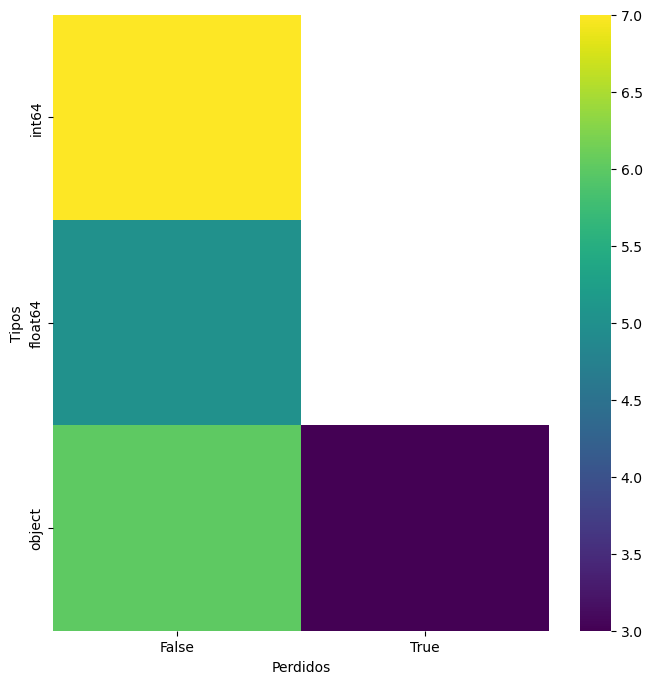

In [172]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Tipos'].value_counts()
    for x_label, grp in perdidos_por_tipo.groupby('Perdidos')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Perdidos')
_ = plt.ylabel('Tipos')

# 14. Volver a cargar los datos

In [174]:
data = cargar_datos()

# 15. Imputar los valores perdidos utilizando la imputación múltiple.

In [175]:
data_num = data2[data2.describe().columns]

In [176]:
data_num.columns

Index(['top_speed_kmh', 'battery_capacity_kWh', 'torque_nm',
       'efficiency_wh_per_km', 'range_km', 'acceleration_0_100_s',
       'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm',
       'width_mm', 'height_mm'],
      dtype='object')

In [177]:
data_no_num = data[data2.columns.difference(data_num.columns)]

In [112]:
!pip install fancyimpute

In [178]:
from fancyimpute import IterativeImputer
my_imputer = IterativeImputer()

datoNumcomp = my_imputer.fit_transform(data_num)
print(type(datoNumcomp))

datoNumcomp = pd.DataFrame(datoNumcomp)

datoNumcomp.columns = data_num.columns

datoNumcomp.index = data_num.index

datos_completos= pd.concat([data_no_num, datoNumcomp], axis=1)


datos_completos

<class 'numpy.ndarray'>


,battery_type,brand,car_body_type,cargo_volume_l,drivetrain,fast_charge_port,model,segment,source_url,top_speed_kmh,...,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
0,Lithium-ion,Abarth,Hatchback,185,FWD,CCS,500e Convertible,B - Compact,https://ev-database.org/car/1904/Abarth-500e-C...,155.0,...,235.0,156.0,225.0,7.0,67.0,0.000000,4.0,3673.0,1683.0,1518.0
1,Lithium-ion,Abarth,Hatchback,185,FWD,CCS,500e Hatchback,B - Compact,https://ev-database.org/car/1903/Abarth-500e-H...,155.0,...,235.0,149.0,225.0,7.0,67.0,0.000000,4.0,3673.0,1683.0,1518.0
2,Lithium-ion,Abarth,SUV,360,FWD,CCS,600e Scorpionissima,JB - Compact,https://ev-database.org/car/3057/Abarth-600e-S...,200.0,...,345.0,158.0,280.0,5.9,79.0,0.000000,5.0,4187.0,1779.0,1557.0
3,Lithium-ion,Abarth,SUV,360,FWD,CCS,600e Turismo,JB - Compact,https://ev-database.org/car/3056/Abarth-600e-T...,200.0,...,345.0,158.0,280.0,6.2,79.0,0.000000,5.0,4187.0,1779.0,1557.0
4,Lithium-ion,Aiways,SUV,496,FWD,CCS,U5,JC - Medium,https://ev-database.org/car/1678/Aiways-U5,150.0,...,310.0,156.0,315.0,7.5,78.0,1052.261062,5.0,4680.0,1865.0,1700.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Lithium-ion,Zeekr,SUV,539,RWD,CCS,7X Premium RWD,JD - Large,https://ev-database.org/car/3081/Zeekr-7X-Prem...,210.0,...,440.0,148.0,365.0,6.0,240.0,2000.000000,5.0,4787.0,1930.0,1650.0
474,Lithium-ion,Zeekr,SUV,362,RWD,CCS,X Core RWD (MY25),JB - Compact,https://ev-database.org/car/3197/Zeekr-X-Core-RWD,190.0,...,343.0,148.0,265.0,5.9,70.0,1600.000000,5.0,4432.0,1836.0,1566.0
475,Lithium-ion,Zeekr,SUV,362,RWD,CCS,X Long Range RWD (MY25),JB - Compact,https://ev-database.org/car/3198/Zeekr-X-Long-...,190.0,...,343.0,146.0,360.0,5.6,114.0,1600.000000,5.0,4432.0,1836.0,1566.0
476,Lithium-ion,Zeekr,SUV,362,AWD,CCS,X Privilege AWD (MY25),JB - Compact,https://ev-database.org/car/3199/Zeekr-X-Privi...,190.0,...,543.0,153.0,350.0,3.8,114.0,1600.000000,5.0,4432.0,1836.0,1566.0


In [179]:
datoNumcomp.isnull().any().any()

False

In [180]:
datos_completos.isnull().any().any()

True

# 16. Guardar los datos.

In [181]:
datos_completos.to_csv(r'C:\americo\ia_dema\10_Valores Perdidos\00_Teoría\ejercicios.csv')

Te mapeo cada paso de tu flujo a los bloques de tu script:

a) Diagnóstico

Lines 1–23: • data = cargar_datos() • data.head(), data.describe(), data.info(). • Cálculo de data.isnull(), .sum(), .mean() y visualizaciones (bar, missingno.matrix, sns.heatmap).

b) Eliminación dura

Lines ~50–65: • Bucle for i in data2: if %nulos > 0.1: drop. • Alternativa to_drop = missing_pct > 30 % + data2 = data.drop(columns=to_drop). • También el snippet data2 = data.loc[:, data.isnull().mean() <= 0.30].

c) Imputación simple

Lines ~85–90: • data2 = data2.fillna(data2.mean(numeric_only=True)). • Luego chequeo de restantes NaN en columnas textuales.

d) Imputación avanzada

Lines ~100–115: • Separación data_num vs data_no_num. • Instalación y uso de IterativeImputer (fancyimpute). • Reconstrucción de datos_completos = pd.concat([...]). • Verificación de no NaN.

e) Export

Lines ~120–122: • datos_completos.to_csv(...ejercicios.csv).